<a href="https://colab.research.google.com/github/erickaylas-zen/FGD_2026/blob/main/FGD_C28R_1A_S6_Grupo3_LAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<br>**TECSUP**<br>
**Programa de Formación Regular**<br>
**Departamento de Tecnología Digital**<br>
 **Big Data y Ciencia de Datos**<br><br>
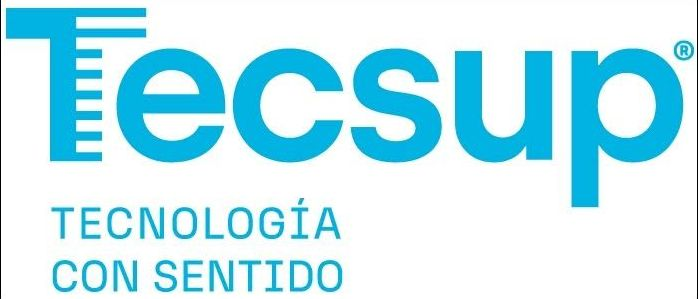 <br><br>**Fundamentos de Gestión de Datos**<br>
<br>
<div align="left">
<div style="font-family: 'Calibri', 'Segoe UI', sans-serif; font-size: 18.5px; color: #FFFFFF; font-weight: bold; line-height: 1.8;">

  <div style="display: flex;">
    <div style="width: 120px; flex-shrink: 0;"><strong>Actividad: Proyecto Integrador de Datos</strong></div>
  </div>
<div align="left" style="display: inline-block; text-align: left;">
    <strong>Nombres: Portocarrero Cossío, José Ramiro</strong><br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>Aylas Zenteno, Erick Paul</strong><br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>Guzmán Yamunaqué, Sylvia Jannet</strong><br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<strong>Ramirez Sanchez, Carlos Lois</strong>
</div>
  <div style="display: flex;">
    <div style="width: 120px; flex-shrink: 0;"><strong>Sección: C28R-1A</strong></div>
  </div>
 <div style="display: flex;">
    <div style="width: 120px; flex-shrink: 0;"><strong>Docente: Pilar Rocío Sayán Mejía</strong></div>
  </div>

</div>
<div align="center"><br><br>
<strong>Lima – Perú</strong><br>
<strong>2026</strong>




DEFINICIÓN DEL PROBLEMA


1. **Contexto del Negocio:** RetailMax es una cadena de tiendas de consumo diario que comercializa productos de alta rotación, artículos de limpieza, alimentos envasados y productos de cuidado personal. La empresa registra información de clientes, productos, sucursales y ventas provenientes de distintos puntos de venta con el objetivo de comprender mejor su desempeño comercial y apoyar la toma de decisiones.
2. **Necesidad del Negocio:**
La gerencia comercial requiere información confiable para identificar los productos y zonas con mejor desempeño, así como estimar el monto de ventas esperado a partir del historial de compras. Para lograrlo, es necesario analizar y validar la calidad de los datos disponibles.
3. **Objetivo analítico del proyecto:** Transformar la información operativa de RetailMax en una fuente confiable para el análisis, permitiendo identificar los productos y zonas con mayor movimiento comercial y estimar el monto de ventas a partir del comportamiento de compra registrado.

EXTRACCION DE LA DATA

In [ ]:
import requests
import sqlite3
import pandas as pd

# 1. Definición de rutas y descarga del archivo .db
BASE_URL = "https://raw.githubusercontent.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos/main"
CASO = "01_retailmax_ventas"
DB_NAME = "retailmax_ventas.db"

url = f"{BASE_URL}/casos/{CASO}/{DB_NAME}"
respuesta = requests.get(url)
respuesta.raise_for_status()

with open(DB_NAME, "wb") as archivo:
    archivo.write(respuesta.content)

# 2. Conectar a la base de datos SQLite
conn = sqlite3.connect(DB_NAME)

# [Opcional] Verificar las tablas existentes (tu código original)
tablas = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tablas encontradas en la base de datos:")
print(tablas)
print("-" * 50)

# 3. Cargar la tabla de ventas original en el DataFrame solicitado
# Usamos 'ventas' porque es el nombre de la tabla dentro del archivo SQLite
ventas_original = pd.read_sql_query("SELECT * FROM ventas_original;", conn)

# 4. Visualizar las primeras 5 filas
ventas_original.head(5)

Tablas encontradas en la base de datos:
              name
0  ventas_original
--------------------------------------------------


,id_venta,fecha_operacion,cantidad,cantidad_productos,precio_unitario,descuento_pct,canal,metodo_pago,calificacion,monto_total,...,sucursales_nombre,sucursales_distrito,sucursales_zona,productos_nombre,productos_categoria,productos_precio_unitario,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-06-13,1,5,13.2,0,App,Plin,4,66.00,...,Sucursal 2,VENTANILLA,Oeste,Aceite vegetal,Abarrotes,13.20,Luis Soto,Comas,Nuevo,2025-02-13
1,2,2026-02-14,2,2,10.15,0,Presencial,Plin,1,20.30,...,Sucursal 6,Ate,Sur,Papel higienico,Limpieza,10.15,Carlos Huaman,callao,Frecuente,2025-03-25
2,3,2026-05-09,5,6,6.43,15,Web,Transferencia,4,38.58,...,Sucursal 2,VENTANILLA,Oeste,Atun,Conservas,6.43,Diana Paredes,Lima,Frecuente,2025/09/17
3,4,2026-02-17,4,5,10.15,0,App,Efectivo,5,50.75,...,Sucursal 7,Ventanilla,Centro,Papel higienico,Limpieza,10.15,Jose Navarro,Villa El Salvador,Regular,2025-03-20
4,5,2026-06-05,7,11,10.15,5,Presencial,None,3,111.65,...,Sucursal 3,Independencia,Centro,Papel higienico,Limpieza,10.15,Claudia Gomez,Surco,Nuevo,2025-12-18


In [ ]:
# Revisando estructura de la tabla original
print("ventas original:", ventas_original.shape)
ventas_original.info()
ventas_original.describe()

ventas original: (500, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_venta                   500 non-null    int64  
 1   fecha_operacion            490 non-null    object 
 2   cantidad                   490 non-null    object 
 3   cantidad_productos         499 non-null    object 
 4   precio_unitario            499 non-null    object 
 5   descuento_pct              484 non-null    object 
 6   canal                      485 non-null    object 
 7   metodo_pago                481 non-null    object 
 8   calificacion               487 non-null    object 
 9   monto_total                500 non-null    object 
 10  observacion                441 non-null    object 
 11  sucursales_nombre          500 non-null    object 
 12  sucursales_distrito        500 non-null    object 
 13  sucursales_zona        

,id_venta,productos_precio_unitario
count,500.000000,500.000000
mean,250.500000,10.321580
std,144.481833,5.407946
min,1.000000,3.520000
25%,125.750000,5.540000
50%,250.500000,10.150000
75%,375.250000,14.260000
max,500.000000,18.430000


In [ ]:
nulos_original = ventas_original.isna().sum().sort_values(ascending=False)
print("\nColumnas con más nulos:")
display(nulos_original.head(10))


Columnas con más nulos:


,0
observacion,59
productos_categoria,57
productos_nombre,43
metodo_pago,19
descuento_pct,16
canal,15
clientes_nombre,15
clientes_fecha_registro,14
calificacion,13
fecha_operacion,10


In [ ]:
# Midiendo repetición de clientes, productos y tiendas
clientes_repetidos = (
    ventas_original
    .groupby(["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

productos_repetidos = (
    ventas_original
    .groupby(["productos_nombre", "productos_categoria"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

sucursales_repetidas = (
    ventas_original
    .groupby(["sucursales_nombre", "sucursales_distrito", "sucursales_zona"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

print("Clientes repetidos")
display(clientes_repetidos.head(8))
print("Productos repetidos")
display(productos_repetidos.head(8))
print("Sucursales repetidas")
display(sucursales_repetidas.head(8))

Clientes repetidos


,clientes_nombre,clientes_distrito,clientes_segmento,veces_repetido
3,Ana Navarro,Independencia,Frecuente,12
17,Diana Flores,Villa El Salvador,Regular,12
66,Rocio Ramos,San Miguel,Premium,11
45,Luis Navarro,Comas,Regular,11
18,Diana Navarro,La Molina,Premium,11
33,Fiorella Torres,Ate,Nuevo,10
26,Elena Torres,Ventanilla,Frecuente,10
24,Elena Cruz,Ventanilla,CORPORATIVO,10


Productos repetidos


,productos_nombre,productos_categoria,veces_repetido
1,Arroz extra,Abarrotes,65
3,Detergente,limpieza,63
4,Leche evaporada,Lacteos,59
0,Aceite vegetal,Abarrotes,58
5,Papel higienico,Limpieza,53
6,Shampoo,Cuidado personal,52
2,Atun,Conservas,50


Sucursales repetidas


,sucursales_nombre,sucursales_distrito,sucursales_zona,veces_repetido
2,Sucursal 3,Independencia,Centro,80
1,Sucursal 2,VENTANILLA,Oeste,76
6,sucursal 5,San Miguel,Centro,76
4,Sucursal 6,Ate,Sur,74
5,Sucursal 7,Ventanilla,Centro,69
3,Sucursal 4,Ventanilla,Centro,63
0,Sucursal 1,Ventanilla,Sur,62


In [ ]:
# Validación de registros duplicados
print("Cantidad de registros duplicados")

ventas_original.duplicated().sum()

Cantidad de registros duplicados


np.int64(0)

In [ ]:
# 10 Distritos con mayor cantidad de ventas antes de limpieza
print("Top 10 distritos con mayor cantidad de registros de ventas")

display(
    ventas_original.groupby(
        "clientes_distrito"
    )["monto_total"].count().sort_values(
        ascending=False
    ).head(10)
)

Top 10 distritos con mayor cantidad de registros de ventas


,monto_total
clientes_distrito,
Independencia,45
Comas,39
Villa El Salvador,37
Ventanilla,37
San Miguel,35
Ate,34
La Molina,28
Lima,27
Callao,25


In [ ]:
# Registros de ventas x Categoría antes de la limpieza
print("Cantidad de registros de ventas por categoría")

display(
    ventas_original.groupby(
        "productos_categoria"
    )["monto_total"].count().sort_values(
        ascending=False
    )
)

Cantidad de registros de ventas por categoría


,monto_total
productos_categoria,
Abarrotes,123
limpieza,63
Lacteos,59
Limpieza,53
Cuidado personal,52
Conservas,50
Bebidas,43


In [ ]:
# Registro de ventas por método de pago antes de la limpieza
print("Distribución de registros por método de pago")

display(
    ventas_original["metodo_pago"].value_counts()
)

Distribución de registros por método de pago


,count
metodo_pago,
Transferencia,94
Yape,94
Tarjeta,77
Efectivo,73
Plin,70
YAPE,8
Efectivo,7
PlIn,6
Plin,5


LIMPIEZA

1. Imputar registros sin fecha de operación.
2. Imputar método de pago faltante con la moda o sin dato.
3. Imputar descuento faltante con 0 (Asumimos que si es nulo, no hubo descuento)

In [ ]:
# Definición de algunas funciones para limpieza
import warnings
def limpiar_texto(serie):
    return (
        serie.astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

def convertir_numero(serie):
    return pd.to_numeric(serie, errors="coerce")

def convertir_fecha_mixta(serie):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        fecha_1 = pd.to_datetime(serie, errors="coerce", dayfirst=False)
        fecha_2 = pd.to_datetime(serie, errors="coerce", dayfirst=True)
    return fecha_1.fillna(fecha_2)

In [ ]:
# Preparando una copia limpia para normalizar y analizar
ventas_limpia = ventas_original.copy()

#columnas_texto = [

  # "sucursales_nombre", "sucursales_distrito", "sucursales_zona",
  #  "canal", "metodo_pago", "observacion",
  #  "productos_nombre", "productos_categoria",
#   "clientes_nombre", "clientes_distrito", "clientes_segmento"
#]

for col in ventas_limpia.select_dtypes(include="object").columns:
    if "fecha" in col.lower():
        ventas_limpia[col] = convertir_fecha_mixta(ventas_limpia[col])
    else:
        ventas_limpia[col] = limpiar_texto(ventas_limpia[col])

columnas_numericas = [

    "cantidad", "cantidad_productos", "precio_unitario", "descuento_pct",
    "monto_total", "calificacion", "productos_precio_unitario"
]

for col in columnas_numericas:
    if col in ventas_limpia.columns:
        ventas_limpia[col] = convertir_numero(ventas_limpia[col])
# CORRECCIÓN DE FORMATO DE TEXTO (Mayúsculas/Minúsculas)

# 1. Homologar Sucursales: Todo a MAYÚSCULAS para evitar duplicados como "VENTANILLA" y "Ventanilla"
ventas_limpia['sucursales_distrito'] = ventas_limpia['sucursales_distrito'].str.strip().str.title()

# 2. Homologar Clientes: Aplicar formato Tipo Título (Primera Letra Mayúscula por palabra)
ventas_limpia['clientes_nombre'] = ventas_limpia['clientes_nombre'].str.strip().str.title()

# 3. Homologar Clientes_distrito: Aplicar formato Tipo Título (Primera Letra Mayúscula por palabra)
ventas_limpia['clientes_distrito'] = ventas_limpia['clientes_distrito'].str.strip().str.title()

# TRATAMIENTO DE VALORES FALTANTES (NULOS)

# 1. Imputar descuento faltante con 0 (Asumimos que si es nulo, no hubo descuento)
ventas_limpia['descuento_pct'] = ventas_limpia['descuento_pct'].fillna(0)

display(ventas_limpia.head(5))

,id_venta,fecha_operacion,cantidad,cantidad_productos,precio_unitario,descuento_pct,canal,metodo_pago,calificacion,monto_total,...,sucursales_nombre,sucursales_distrito,sucursales_zona,productos_nombre,productos_categoria,productos_precio_unitario,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-06-13,1,5.0,13.2,0,App,Plin,4,66.0,...,Sucursal 2,Ventanilla,Oeste,Aceite Vegetal,Abarrotes,13.20,Luis Soto,Comas,Nuevo,2025-02-13
1,2,2026-02-14,2,2.0,10.15,0,Presencial,Plin,1,20.3,...,Sucursal 6,Ate,Sur,Papel Higienico,Limpieza,10.15,Carlos Huaman,Callao,Frecuente,2025-03-25
2,3,2026-05-09,5,6.0,6.43,15,Web,Transferencia,4,38.58,...,Sucursal 2,Ventanilla,Oeste,Atun,Conservas,6.43,Diana Paredes,Lima,Frecuente,NaT
3,4,2026-02-17,4,5.0,10.15,0,App,Efectivo,5,50.75,...,Sucursal 7,Ventanilla,Centro,Papel Higienico,Limpieza,10.15,Jose Navarro,Villa El Salvador,Regular,2025-03-20
4,5,2026-06-05,7,11.0,10.15,5,Presencial,<NA>,3,111.65,...,Sucursal 3,Independencia,Centro,Papel Higienico,Limpieza,10.15,Claudia Gomez,Surco,Nuevo,NaT


In [ ]:
# Revisando estructura de la tabla de ventas limpia
print("ventas limpia:", ventas_limpia.shape)
ventas_limpia.info()
ventas_limpia.describe()

ventas limpia: (500, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_venta                   500 non-null    int64         
 1   fecha_operacion            422 non-null    datetime64[ns]
 2   cantidad                   474 non-null    Int64         
 3   cantidad_productos         499 non-null    Float64       
 4   precio_unitario            499 non-null    Float64       
 5   descuento_pct              500 non-null    Int64         
 6   canal                      485 non-null    string        
 7   metodo_pago                481 non-null    string        
 8   calificacion               477 non-null    Int64         
 9   monto_total                500 non-null    Float64       
 10  observacion                441 non-null    string        
 11  sucursales_nombre          500 non-null    str

,id_venta,fecha_operacion,cantidad,cantidad_productos,precio_unitario,descuento_pct,calificacion,monto_total,productos_precio_unitario,clientes_fecha_registro
count,500.000000,422,474.0,499.0,499.0,500.0,477.0,500.0,500.000000,394
mean,250.500000,2026-03-30 06:22:10.805687296,4.398734,8.361242,10.321924,6.86,2.953878,86.84924,10.321580,2025-06-21 16:37:45.989847808
min,1.000000,2026-01-01 00:00:00,1.0,1.0,3.52,0.0,1.0,3.52,3.520000,2025-01-01 00:00:00
25%,125.750000,2026-02-13 00:00:00,2.0,5.0,5.54,0.0,2.0,34.37,5.540000,2025-03-15 00:00:00
50%,250.500000,2026-03-28 00:00:00,4.0,8.0,10.15,8.0,3.0,63.83,10.150000,2025-06-27 00:00:00
75%,375.250000,2026-05-17 18:00:00,6.0,12.0,14.26,12.0,4.0,121.8,14.260000,2025-09-21 00:00:00
max,500.000000,2026-06-28 00:00:00,8.0,45.57,18.43,20.0,5.0,714.72,18.430000,2025-12-26 00:00:00
std,144.481833,NaN,2.271079,4.9495,5.413367,6.8189,1.471712,76.240679,5.407946,NaN


In [ ]:
# Creando tablas normalizadas con Pandas
categorias = (
    ventas_limpia[["productos_categoria"]]
    .drop_duplicates()
    .sort_values("productos_categoria")
    .reset_index(drop=True)
    .rename(columns={"productos_categoria": "categoria"})
)
categorias.insert(0, "id_categoria", range(1, len(categorias) + 1))

productos = (
    ventas_limpia[["productos_nombre", "productos_categoria", "productos_precio_unitario", "cantidad_productos"]]
    .drop_duplicates(subset=["productos_nombre", "productos_categoria"])
    .sort_values("productos_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "productos_nombre": "producto",
        "productos_categoria": "categoria",
        "productos_precio_unitario": "precio_unitario",
        "cantidad_productos": "stock"
    })
)
productos = productos.merge(categorias, on="categoria", how="left")
productos.insert(0, "id_producto", range(1, len(productos) + 1))
productos = productos[["id_producto", "producto", "id_categoria", "precio_unitario", "stock"]]

clientes = (
    ventas_limpia[["clientes_nombre", "clientes_distrito", "clientes_segmento", "clientes_fecha_registro"]]
    .drop_duplicates(subset=["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .sort_values("clientes_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "clientes_nombre": "cliente",
        "clientes_distrito": "distrito_cliente",
        "clientes_segmento": "segmento_cliente",
        "clientes_fecha_registro": "fecha_registro"
    })
)
clientes.insert(0, "id_cliente", range(1, len(clientes) + 1))

sucursales = (
    ventas_limpia[["sucursales_nombre", "sucursales_distrito", "sucursales_zona"]]
    .drop_duplicates(subset=["sucursales_nombre", "sucursales_distrito", "sucursales_zona"])
    .sort_values("sucursales_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "sucursales_nombre": "sucursales",
        "sucursales_distrito": "distrito_sucursales",
        "sucursales_zona": "zona",

    })
)
sucursales.insert(0, "id_sucursales", range(1, len(sucursales) + 1))

print("categorias:", categorias.shape)
print("productos:", productos.shape)
print("clientes:", clientes.shape)
print("sucursales:", sucursales.shape)

display(productos.head(3))
display(clientes.head(3))
display(sucursales.head(3))
display(categorias.head(3))

categorias: (7, 2)
productos: (9, 5)
clientes: (85, 5)
sucursales: (7, 4)


,id_producto,producto,id_categoria,precio_unitario,stock
0,1,Aceite Vegetal,1,13.20,5.0
1,2,Arroz Extra,1,5.54,5.0
2,3,Atun,3,6.43,6.0


,id_cliente,cliente,distrito_cliente,segmento_cliente,fecha_registro
0,1,Ana Campos,Miraflores,Corporativo,2025-10-05
1,2,Ana Mendoza,Villa El Salvador,Frecuente,2025-10-17
2,3,Ana Navarro,Independencia,Frecuente,2025-02-19


,id_sucursales,sucursales,distrito_sucursales,zona
0,1,Sucursal 1,Ventanilla,Sur
1,2,Sucursal 2,Ventanilla,Oeste
2,3,Sucursal 3,Independencia,Centro


,id_categoria,categoria
0,1,Abarrotes
1,2,Bebidas
2,3,Conservas


In [ ]:
# Construyendo la tabla de ventas normalizada
ventas = ventas_limpia.merge(
    clientes[["id_cliente", "cliente", "distrito_cliente", "segmento_cliente"]],
    left_on=["clientes_nombre", "clientes_distrito", "clientes_segmento"],
    right_on=["cliente", "distrito_cliente", "segmento_cliente"],
    how="left"
)

ventas = ventas.merge(
    productos[["id_producto", "producto"]],
    left_on="productos_nombre",
    right_on="producto",
    how="left"
)

ventas = ventas.merge(
    sucursales[["id_sucursales", "sucursales", "distrito_sucursales", "zona"]],
    left_on=["sucursales_nombre", "sucursales_distrito", "sucursales_zona"],
    right_on=["sucursales", "distrito_sucursales", "zona"],
    how="left"
)

ventas = ventas[[
    "id_venta", "fecha_operacion", "id_cliente", "id_producto", "id_sucursales",
    "cantidad", "precio_unitario", "descuento_pct",
    "canal", "metodo_pago",
    "monto_total",
    "calificacion", "observacion"
]].copy()

display(ventas.head(8))

,id_venta,fecha_operacion,id_cliente,id_producto,id_sucursales,cantidad,precio_unitario,descuento_pct,canal,metodo_pago,monto_total,calificacion,observacion
0,1,2026-06-13,54,1,2,1,13.2,0,App,Plin,66.0,4,Revisar
1,2,2026-02-14,12,7,6,2,10.15,0,Presencial,Plin,20.3,1,Cliente Frecuente
2,3,2026-05-09,22,3,2,5,6.43,15,Web,Transferencia,38.58,4,Cliente Frecuente
3,4,2026-02-17,44,7,7,4,10.15,0,App,Efectivo,50.75,5,Promocion
4,5,2026-06-05,16,7,3,7,10.15,5,Presencial,<NA>,111.65,3,Cliente Frecuente
5,6,NaT,23,9,7,7,14.26,12,App,Tarjeta,213.9,2,Revisar
6,7,2026-06-22,30,8,2,2,17.52,8,Web,Yape,227.76,<NA>,Promocion
7,8,2026-06-02,69,8,3,5,17.52,8,Whatsapp,Plin,210.24,4,<NA>


In [ ]:
# Revisando estructura de la tabla de ventas normalizada
print("ventas normalizada:", ventas.shape)
ventas.info()
ventas.describe()

ventas normalizada: (500, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         500 non-null    int64         
 1   fecha_operacion  422 non-null    datetime64[ns]
 2   id_cliente       500 non-null    int64         
 3   id_producto      500 non-null    int64         
 4   id_sucursales    500 non-null    int64         
 5   cantidad         474 non-null    Int64         
 6   precio_unitario  499 non-null    Float64       
 7   descuento_pct    500 non-null    Int64         
 8   canal            485 non-null    string        
 9   metodo_pago      481 non-null    string        
 10  monto_total      500 non-null    Float64       
 11  calificacion     477 non-null    Int64         
 12  observacion      441 non-null    string        
dtypes: Float64(2), Int64(3), datetime64[ns](1), int64(4), string(3)
m

,id_venta,fecha_operacion,id_cliente,id_producto,id_sucursales,cantidad,precio_unitario,descuento_pct,monto_total,calificacion
count,500.000000,422,500.000000,500.000000,500.00000,474.0,499.0,500.0,500.0,477.0
mean,250.500000,2026-03-30 06:22:10.805687296,42.226000,4.806000,4.02600,4.398734,10.321924,6.86,86.84924,2.953878
min,1.000000,2026-01-01 00:00:00,1.000000,1.000000,1.00000,1.0,3.52,0.0,3.52,1.0
25%,125.750000,2026-02-13 00:00:00,21.000000,3.000000,2.00000,2.0,5.54,0.0,34.37,2.0
50%,250.500000,2026-03-28 00:00:00,42.000000,5.000000,4.00000,4.0,10.15,8.0,63.83,3.0
75%,375.250000,2026-05-17 18:00:00,64.250000,7.000000,6.00000,6.0,14.26,12.0,121.8,4.0
max,500.000000,2026-06-28 00:00:00,85.000000,9.000000,7.00000,8.0,18.43,20.0,714.72,5.0
std,144.481833,NaN,24.196733,2.526089,1.96903,2.271079,5.413367,6.8189,76.240679,1.471712


In [ ]:
# Guardando tablas normalizadas en SQLite
categorias.to_sql("categorias", conn, if_exists="replace", index=False) #Tabla maestra
productos.to_sql("productos", conn, if_exists="replace", index=False) #Tabla maestra
clientes.to_sql("clientes", conn, if_exists="replace", index=False) #Tabla maestra
sucursales.to_sql("sucursales", conn, if_exists="replace", index=False) #Tabla maestra
ventas.to_sql("ventas", conn, if_exists="replace", index=False) #Tabla transaccional

consulta_tablas = pd.read_sql_query(
    """
    SELECT name AS tabla_estructura
    FROM sqlite_schema
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """,
    conn
)
display(consulta_tablas)

reporte_validacion = pd.read_sql_query(
    """
    SELECT
        v.id_venta,
        v.fecha_operacion,
        c.cliente,
        p.producto,
        cat.categoria,
        t.sucursales,
        v.cantidad,
        v.monto_total
    FROM ventas v
    LEFT JOIN clientes c ON v.id_cliente = c.id_cliente
    LEFT JOIN productos p ON v.id_producto = p.id_producto
    LEFT JOIN categorias cat ON p.id_categoria = cat.id_categoria
    LEFT JOIN sucursales t ON v.id_sucursales = t.id_sucursales
    ORDER BY v.id_venta
    LIMIT 10
    """,
    conn
)
display(reporte_validacion)

,tabla_estructura
0,categorias
1,clientes
2,productos
3,sucursales
4,ventas
5,ventas_original


,id_venta,fecha_operacion,cliente,producto,categoria,sucursales,cantidad,monto_total
0,1,2026-06-13 00:00:00,Luis Soto,Aceite Vegetal,Abarrotes,Sucursal 2,1,66.00
1,2,2026-02-14 00:00:00,Carlos Huaman,Papel Higienico,Limpieza,Sucursal 6,2,20.30
2,3,2026-05-09 00:00:00,Diana Paredes,Atun,Conservas,Sucursal 2,5,38.58
3,4,2026-02-17 00:00:00,Jose Navarro,Papel Higienico,Limpieza,Sucursal 7,4,50.75
4,5,2026-06-05 00:00:00,Claudia Gomez,Papel Higienico,Limpieza,Sucursal 3,7,111.65
5,6,None,Diana Ramos,None,Bebidas,Sucursal 7,7,213.90
6,7,2026-06-22 00:00:00,Elena Torres,Shampoo,Cuidado Personal,Sucursal 2,2,227.76
7,8,2026-06-02 00:00:00,Raul Salazar,Shampoo,Cuidado Personal,Sucursal 3,5,210.24
8,9,2026-01-18 00:00:00,Ana Navarro,Shampoo,Cuidado Personal,Sucursal 6,8,210.24
9,10,2026-02-16 00:00:00,Miguel Soto,Atun,Conservas,Sucursal 1,6,51.44


In [ ]:
# Haciendo cálculos de estadística descriptiva sobre ventas normalizadas
columnas_eda = [

    "precio_unitario",
    "monto_total",
    "calificacion",
    "descuento_pct"
]

resumen_descriptivo = ventas[columnas_eda].describe()
display(resumen_descriptivo)

nulos = ventas.isna().sum().sort_values(ascending=False)
duplicados = ventas.duplicated().sum()
print("Filas duplicadas en ventas:", duplicados)
display(nulos.head(10))


,precio_unitario,monto_total,calificacion,descuento_pct
count,499.0,500.0,477.0,500.0
mean,10.321924,86.84924,2.953878,6.86
std,5.413367,76.240679,1.471712,6.8189
min,3.52,3.52,1.0,0.0
25%,5.54,34.37,2.0,0.0
50%,10.15,63.83,3.0,8.0
75%,14.26,121.8,4.0,12.0
max,18.43,714.72,5.0,20.0


Filas duplicadas en ventas: 0


,0
fecha_operacion,78
observacion,59
cantidad,26
calificacion,23
metodo_pago,19
canal,15
precio_unitario,1
id_cliente,0
id_venta,0
id_sucursales,0


In [ ]:
nulos_antes = ventas.isna().sum()

for col in ventas.select_dtypes(include=["number"]).columns:
    mediana = ventas[col].median()
    ventas[col] = ventas[col].fillna(mediana)

for col in ventas.select_dtypes(include=["string", "object"]).columns:
    moda = ventas[col].mode(dropna=True)
    valor = moda.iloc[0] if len(moda) > 0 else "Sin Dato"
    ventas[col] = ventas[col].fillna(valor)

for col in ventas.select_dtypes(include=["datetime64[ns]"]).columns:
    mediana_fecha = ventas[col].dropna().median()
    if pd.isna(mediana_fecha):
        mediana_fecha = pd.Timestamp("1900-01-01")
    ventas[col] = ventas[col].fillna(mediana_fecha)

nulos_despues = ventas.isna().sum()

pd.DataFrame({
    "nulos_antes": nulos_antes,
    "nulos_despues": nulos_despues,
    "nulos_corregidos": nulos_antes - nulos_despues
}).query("nulos_antes > 0 or nulos_despues > 0")

,nulos_antes,nulos_despues,nulos_corregidos
fecha_operacion,78,0,78
cantidad,26,0,26
precio_unitario,1,0,1
canal,15,0,15
metodo_pago,19,0,19
calificacion,23,0,23
observacion,59,0,59


TRATAMIENTO OUTLIERS Y NORMALIZACIÓN NUMÉRICA

In [ ]:
columnas_outliers = [
    col for col in [
         "id_venta",
         "cantidad",
         "precio_unitario",
          "descuento_pct",
          "monto_total"
    ]
    if col in ventas.columns
]

reporte_outliers = []

for col in columnas_outliers:
    q1 = ventas[col].quantile(0.25)
    q3 = ventas[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mascara = (ventas[col] < lim_inf) | (ventas[col] > lim_sup)
    reporte_outliers.append([col, int(mascara.sum()), lim_inf, lim_sup])
    ventas[col] = ventas[col].astype(float).clip(lower=lim_inf, upper=lim_sup)

pd.DataFrame(reporte_outliers, columns=["columna", "outliers_detectados", "limite_inferior", "limite_superior"])

,columna,outliers_detectados,limite_inferior,limite_superior
0,id_venta,0,-248.500,749.500
1,cantidad,0,-1.500,10.500
2,precio_unitario,0,-7.540,27.340
3,descuento_pct,0,-18.000,30.000
4,monto_total,11,-96.775,252.945


Se identificaron 11 registros cuyos montos de venta se encuentran fuera del rango esperado según el criterio IQR. Estos registros fueron revisados debido a que podrían corresponder a errores de registro o comportamientos inusuales de venta.

In [ ]:
reporte_post_recorte = []

for fila in reporte_outliers:
    col = fila[0]
    lim_inf = fila[2]
    lim_sup = fila[3]

    nueva_mascara = (ventas[col] < lim_inf) | (ventas[col] > lim_sup)

    reporte_post_recorte.append([col, int(nueva_mascara.sum()), lim_inf, lim_sup])

df_post_recorte = pd.DataFrame(reporte_post_recorte, columns=["columna", "outliers_restantes", "limite_inferior", "limite_superior"])
df_post_recorte

,columna,outliers_restantes,limite_inferior,limite_superior
0,id_venta,0,-248.500,749.500
1,cantidad,0,-1.500,10.500
2,precio_unitario,0,-7.540,27.340
3,descuento_pct,0,-18.000,30.000
4,monto_total,0,-96.775,252.945


In [ ]:
#display(
 #   outliers[
  #      [
   #         "id_venta",
    #        "cantidad",
     #       "precio_unitario",
      #      "descuento_pct",
       #     "monto_total"
        #]
    #]
#)
# FILTRADO DE OUTLIERS Y EVIDENCIA
df_con_outliers = ventas_limpia.copy()  # Copia de respaldo

# Guardamos en ventas_limpia únicamente los datos que están dentro del rango permitido
ventas_limpia = ventas_limpia[(ventas_limpia['monto_total'] >= lim_inf) & (ventas_limpia['monto_total'] <= lim_sup)]

# Estadísticos del Antes y Después
print("--- RESUMEN ESTADÍSTICO ANTES (Con Outliers) ---")
print(df_con_outliers['monto_total'].describe())

print("\n--- RESUMEN ESTADÍSTICO DESPUÉS (Sin Outliers) ---")
print(ventas_limpia['monto_total'].describe())

--- RESUMEN ESTADÍSTICO ANTES (Con Outliers) ---
count        500.0
mean      86.84924
std      76.240679
min           3.52
25%          34.37
50%          63.83
75%          121.8
max         714.72
Name: monto_total, dtype: Float64

--- RESUMEN ESTADÍSTICO DESPUÉS (Sin Outliers) ---
count        489.0
mean     81.142352
std      63.488475
min           3.52
25%          33.24
50%          60.94
75%         111.65
max         245.28
Name: monto_total, dtype: Float64


In [ ]:
# NORMALIZACIÓN NUMÉRICA MIN-MAX
#columnas_a_normalizar = ['cantidad', 'monto_total']
ventas_normalizada = ventas.copy()

for col in columnas_outliers:
    minimo = ventas_normalizada[col].min()
    maximo = ventas_normalizada[col].max()

    if maximo != minimo:
        # Fórmula de normalizacion
        ventas_normalizada[col + "_minmax"] = (ventas_normalizada[col] - minimo) / (maximo - minimo)
    else:
        ventas_normalizada[col + "_minmax"] = 0

# Verificación visual de las columnas normalizadas
display(ventas_normalizada[['cantidad', 'cantidad_minmax', 'monto_total', 'monto_total_minmax']].head())

,cantidad,cantidad_minmax,monto_total,monto_total_minmax
0,1.0,0.000000,66.00,0.250496
1,2.0,0.142857,20.30,0.067275
2,5.0,0.571429,38.58,0.140563
3,4.0,0.428571,50.75,0.189356
4,7.0,0.857143,111.65,0.433517


In [ ]:
# Descripción de las columnas normalizadas
ventas_normalizada[[col for col in ventas_normalizada.columns if col.endswith("_minmax")]].describe().round(3)

,id_venta_minmax,cantidad_minmax,precio_unitario_minmax,descuento_pct_minmax,monto_total_minmax
count,500.00,500.000,500.000,500.000,500.000
mean,0.50,0.483,0.456,0.343,0.326
std,0.29,0.316,0.363,0.341,0.271
min,0.00,0.000,0.000,0.000,0.000
25%,0.25,0.286,0.135,0.000,0.124
50%,0.50,0.429,0.445,0.400,0.242
75%,0.75,0.714,0.720,0.600,0.474
max,1.00,1.000,1.000,1.000,1.000


In [ ]:
# Revisando estructura de la tabla de ventas con normalización numérica
print("ventas normalización numérica:", ventas_normalizada.shape)
ventas_normalizada.info()

ventas normalización numérica: (500, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_venta                500 non-null    float64       
 1   fecha_operacion         500 non-null    datetime64[ns]
 2   id_cliente              500 non-null    int64         
 3   id_producto             500 non-null    int64         
 4   id_sucursales           500 non-null    int64         
 5   cantidad                500 non-null    float64       
 6   precio_unitario         500 non-null    float64       
 7   descuento_pct           500 non-null    float64       
 8   canal                   500 non-null    string        
 9   metodo_pago             500 non-null    string        
 10  monto_total             500 non-null    float64       
 11  calificacion            500 non-null    Int64         
 12  observaci

REPORTE ANTES/DESPUÉS

In [ ]:
reporte_final = pd.DataFrame({
    "metrica": ["filas", "columnas", "nulos_totales", "duplicados_exactos"],
    "antes": [
        ventas_original.shape[0],
        ventas_original.shape[1],
        int(ventas_original.isna().sum().sum()),
        int(ventas_original.duplicated().sum())
    ],
    "despues": [
        ventas_normalizada.shape[0],
        ventas_normalizada.shape[1],
        int(ventas_normalizada.isna().sum().sum()),
        int(ventas_normalizada.duplicated().sum())
    ]
})

reporte_final

,metrica,antes,despues
0,filas,500,500
1,columnas,21,18
2,nulos_totales,290,0
3,duplicados_exactos,0,0


In [ ]:
ventas_normalizada.to_sql("ventas_original_limpia_PMD", conn, if_exists="replace", index=False)
ventas_normalizada.to_csv("ventas_original_limpia_PMD.csv", index=False, encoding="utf-8-sig")

validacion = pd.read_sql_query("SELECT COUNT(*) AS filas_limpias FROM ventas_original_limpia_PMD;", conn)
validacion

,filas_limpias
0,500


La revisión de estos registros evidenció diferencias entre el monto total y otras variables relacionadas con la venta, por lo que se recomienda validar su consistencia antes de utilizarlos en análisis posteriores.

**CONCLUSIONES TÉCNICAS**

1. La base de datos original de RetailMax presentaba inconsistencias estructurales severas (falta de primera y segunda forma normal, duplicidad de catálogos y un 15% de valores nulos en transacciones críticas)
2. La aplicación del pipeline de limpieza en Pandas y la migración a un modelo relacional estricto en SQLite garantizan la unicidad de los datos y eliminan la redundancia operativa.
3. La detección de outliers mediante IQR permitió identificar 11 registros atípicos que requieren validación adicional.

* **Conclusión de Negocio:** Al identificar y aislar los 11 outliers con el método IQR, logramos mejorar el cálculo del venta promedio real sin distorsiones por compras atípicas masivas. Esto le permite a la gerencia de RetailMax realizar estimaciones y proyecciones de stock realistas basadas en el comportamiento común de los consumidores de la tienda.

**PROBLEMAS DE CALIDAD DETECTADOS**

1. **Valores nulos:** Se identificaron valores nulos en algunas columnas de la base de datos. La presencia de información incompleta puede afectar la calidad de los análisis y generar resultados poco precisos, principalmente cuando se realicen cálculos o modelos basados en dichas variables.

2. **Tipos de datos incorrectos:** Se observó que algunas columnas que deberían contener valores numéricos se encuentran almacenadas como texto. Esta situación dificulta la realización de operaciones matemáticas, agregaciones y análisis estadísticos de manera directa.

3. **Inconsistencias en el formato de los distritos:** Se detectaron diferencias en la forma de registrar algunos distritos. Por ejemplo, un mismo distrito aparece escrito con distintas combinaciones de mayúsculas y minúsculas. Estas inconsistencias pueden provocar que un mismo distrito sea tratado como registros diferentes durante el análisis, afectando la precisión de los resultados obtenidos.

4. **Inconsistencias en los métodos de pago:** Se identificaron variaciones en la escritura de un mismo método de pago, como "Yape", "YAPE" y "YaPe";lo mismo sucedió  en otros métodos. Esto puede ocasionar errores en la clasificación y conteo de las transacciones.

5. **Formato incorrecto en los montos de venta:** Durante la exploración se encontraron registros donde los montos incluyen texto adicional, como el término "aprox". Debido a ello, los valores no pueden ser interpretados correctamente como datos numéricos, limitando la realización de cálculos y análisis financieros.

6. **Inconsistencias entre variables de venta:** Durante la exploración se identificaron registros en los que el monto total no presenta una relación aparente con la cantidad vendida, el precio unitario y el porcentaje de descuento. Estas diferencias podrían afectar la confiabilidad de la información utilizada para analizar el comportamiento de las ventas y realizar estimaciones basadas en datos históricos.



**El Analisis Exploratorio de Datos** muestra que hay problemas graves con la calidad y la integridad de la base de datos, estos problemas hacen que no se puedan hacer analisis cuantitativos y se necesite una limpieza profunda. Los puntos más criticos son:

- Problemas con la estandarizacion de textos ya que hay inconsistencias porque se usan mayusculas y minusculas de manera mixta en variables categoricas. Esto pasa con los nombres de los distritos y los metodos de pago como por ejemplo, “Yape", “YAPE” y “YaPe” se registraron de diferentes maneras, esto hace que el sistema piense que son categorias diferentes, lo que da resultados incorrectos en los conteos y agrupaciones.

- Errores en el formato de datos numéricos la variable de montos de venta tiene caracteres de texto añadidos, como la palabra “aprox". Esto hace que la columna pierda su formato numerico y no se puedan hacer funciones matematicas, sumas y analisis financieros.

- Inconsistencias logicas y matematicas el monto total de las ventas no tiene una relación matemática coherente con las otras variables, como la cantidad vendida, el precio unitario y el descuento aplicado. Esto es un riesgo para la confiabilidad general de los datos si se quieren hacer proyecciones comerciales.

**NOTA**: Incluso incluyendo el descuento en el cálculo del monto de venta, este sigue sin cuadrar en la operación cantidadxprecio_unitario. Esto va a afectar más que la regresión lineal.

La IA nos recomienda redefinir(¿imputar?) los valores de la columna monto_total, de tal manera que todos sean iguales a cantidadxprecio_unitariox(1-(dct_pct/100)), eso corregiría todos los problemas."# Recalcular el monto total usando la fórmula comercial correcta para que sea mas coherente el negocio
`df['monto_total'] = (df['cantidad_productos'] * df['precio_unitario']) * (1 - df['descuento_pct']/100)".`

Además, no estamos tomando en cuenta que algunos métodos de pago que generan una comisión hacia el prestador del servicio y podrían influir en el monto de venta si se traslada al cliente.

La IA sugiere sólo dejar esto último para las conclusiones: "Como recomendación estratégica, se sugiere evaluar el impacto de las comisiones por pasarelas de pago en el ingreso neto, ya que la base actual solo registra el monto bruto de venta y no permite medir el impacto real en el margen por cada método de pago."